--- ANÁLISIS DE MOMENTOS DE HU Y VÉRTICES ---

[Figura 1]: Detectada como -> Triangulo
 Cantidad de vértices detectados: 3
 Primeros 3 Momentos de Hu (Log transform): [np.float64(0.7112044614883409), np.float64(3.113068362258711), np.float64(2.3344730597762315)]

[Figura 2]: Detectada como -> Poligono (8 vertices)
 Cantidad de vértices detectados: 8
 Primeros 3 Momentos de Hu (Log transform): [np.float64(0.7981604332752787), np.float64(29.778393617258022), np.float64(27.803381501291664)]

[Figura 3]: Detectada como -> Cuadrado
 Cantidad de vértices detectados: 4
 Primeros 3 Momentos de Hu (Log transform): [np.float64(0.7781512503836436), 0, 0]


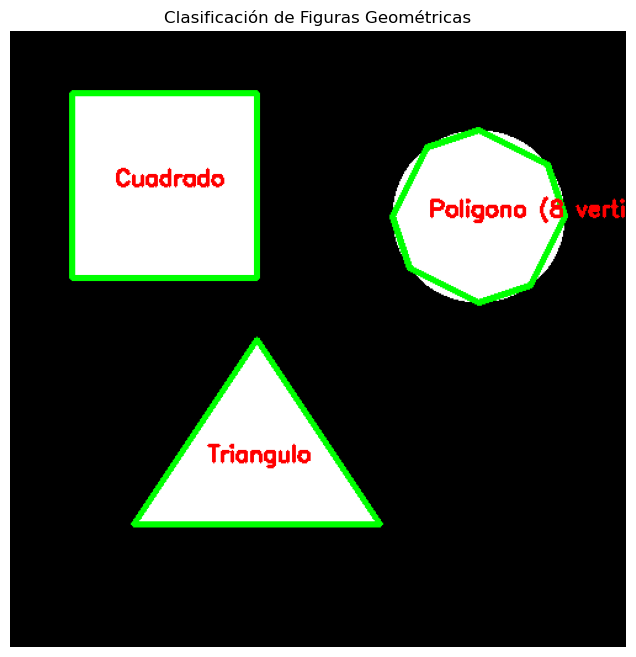

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CREACIÓN DE UNA IMAGEN DE PRUEBA (Opcional si ya tienes una) ---
# Si tienes tu propia imagen, descomenta la siguiente línea y cambia la ruta:
# imagen = cv2.imread('ruta_de_tu_imagen.png')

# Creamos un lienzo negro para dibujar figuras de prueba
imagen = np.zeros((500, 500, 3), dtype=np.uint8)

# Dibujar un triángulo
pts_triangulo = np.array([[100, 400], [200, 250], [300, 400]], np.int32)
cv2.drawContours(imagen, [pts_triangulo], 0, (255, 255, 255), -1)

# Dibujar un cuadrado
cv2.rectangle(imagen, (50, 50), (200, 200), (255, 255, 255), -1)

# Dibujar un círculo
cv2.circle(imagen, (380, 150), 70, (255, 255, 255), -1)


# --- 2. PROCESAMIENTO DE IMAGEN ---
# Pasar a escala de grises y binarizar
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, binarizada = cv2.threshold(gris, 50, 255, cv2.THRESH_BINARY)

# Encontrar los contornos de las figuras
contornos, _ = cv2.findContours(binarizada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copia de la imagen original para dibujar los resultados sobre ella
resultado = imagen.copy()


# --- 3. ANÁLISIS Y CLASIFICACIÓN DE CADA FIGURA ---
print("--- ANÁLISIS DE MOMENTOS DE HU Y VÉRTICES ---")

for i, contorno in enumerate(contornos):
    # Calcular momentos geométricos de la figura
    momentos = cv2.moments(contorno)
    
    # Calcular Momentos de Hu (cv2.HuMoments)
    hu_moments = cv2.HuMoments(momentos)
    # Los momentos de Hu suelen ser valores muy pequeños, se les aplica logaritmo para mejor lectura
    hu_log = [-1 * np.sign(h) * np.log10(abs(h)) if h != 0 else 0 for h in hu_moments.flatten()]
    
    # Calcular el centroide (centro) de la figura para colocar el texto
    if momentos["m00"] != 0:
        cx = int(momentos["m10"] / momentos["m00"])
        cy = int(momentos["m01"] / momentos["m00"])
    else:
        cx, cy = 0, 0

    # Aproximación del contorno con cv2.approxPolyDP para contar vértices
    # El parámetro epsilon controla la precisión de la aproximación
    epsilon = 0.03 * cv2.arcLength(contorno, True)
    aproximacion = cv2.approxPolyDP(contorno, epsilon, True)
    vertices = len(aproximacion)
    
    # Clasificación de la figura según sus vértices
    if vertices == 3:
        forma = "Triangulo"
    elif vertices == 4:
        # Podría ser cuadrado o rectángulo, asumimos cuadrado para la práctica básica
        forma = "Cuadrado"
    elif vertices > 8:
        # Una figura con muchos vértices aproximados suele ser un círculo
        forma = "Circulo"
    else:
        forma = f"Poligono ({vertices} vertices)"

    # Imprimir en consola de Jupyter los momentos de Hu solicitados
    print(f"\n[Figura {i+1}]: Detectada como -> {forma}")
    print(f" Cantidad de vértices detectados: {vertices}")
    print(f" Primeros 3 Momentos de Hu (Log transform): {hu_log[:3]}")

    # Dibujar el contorno aproximado y poner el nombre de la figura en la imagen
    cv2.drawContours(resultado, [aproximacion], -1, (0, 255, 0), 3)
    cv2.putText(resultado, forma, (cx - 40, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# --- 4. VISUALIZACIÓN EN JUPYTER ---
# Convertir BGR a RGB para mostrar correctamente con Matplotlib
resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(resultado_rgb)
plt.title("Clasificación de Figuras Geométricas")
plt.axis("off")
plt.show()